# Records Matching

DS 6105 | Summer 2026

**Know Their Names Capstone**

## Import Data 

In [38]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb # Using this for joins
import ipywidgets as widgets
from IPython.display import display

In [39]:
con = duckdb.connect()

### MENTION

In [40]:
mention_file = "./sources/all_mentions.csv"
mention_cols_to_drop = ['original_data','created','county','maiden_name','death_year','narrative'] # 'location_id','source_year','source'
MENTION = (
    pd.read_csv(mention_file, low_memory=False)
    .set_index('mention_id')
    .drop(mention_cols_to_drop, axis=1)
    .drop_duplicates()
)

In [41]:
MENTION['birth_year'] = MENTION.birth_year.astype('Int64')

**Define a Person Key**

In [42]:
key_cols = ['birth_year', 'legal_status', 'norm_race', 'gender', 'full_name']
def make_key_str(x):
    return "-".join([str(v).replace(" ","_").lower() for v in x]).replace("nan","x").replace("<na>","xxxx")
MENTION['person_key'] = MENTION[key_cols].apply(make_key_str, axis=1)

In [43]:
_ = con.register('mention', MENTION.reset_index())

In [44]:
MENTION

,source,source_year,confidence,full_name,first_name,middle_name,last_name,birth_year,race,gender,...,norm_first_name,nysiis_last_name,norm_race,norm_occupation,enslaver_id,location_id,head,household_id,family_id,person_key
mention_id,,,,,,,,,,,,,,,,,,,,,
a632802a-a920-4a60-b231-504c103e1bbe,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,1824,B,M,...,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,1824-e-b-m-x
e4cf1dc7-dc28-478f-989c-8d1be7c0f33b,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,1826,B,M,...,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,1826-e-b-m-x
e0153e40-ebba-4de8-bd4c-9cb8298668bd,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,1808,M,F,...,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,1808-e-b-f-x
d7fd0920-495a-45af-82b6-cf77b4605d92,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,1807,B,M,...,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,1807-e-b-m-x
e9c5aec0-c140-4f08-9a86-caf8d4e9d734,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,1812,M,M,...,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,1812-e-b-m-x
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
d1fcc13a-9c5d-49c0-906d-dca04a151291,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,1755,B,M,...,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,1755-e-b-m-x
5da36709-add9-4aad-9a6d-f91ab4e09042,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,1788,M,F,...,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,1788-e-b-f-x
583e9fa5-5333-4fc2-9631-ddb695993402,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,1801,B,M,...,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,1801-e-b-m-x


### ASSERTION

In [47]:
assertion_file = "./sources/all_assertions.csv"
assertion_cols_to_drop = ['created','object_string','county']
ASSERTION = (
    pd.read_csv(assertion_file, low_memory=False)
    .set_index(['predicate', 'object_id', 'subject_id'])
    .drop(assertion_cols_to_drop, axis=1)
    .drop_duplicates()
)

In [48]:
ASSERTION

assertion_id  \
predicate      object_id                            subject_id                                                                   
isSiblingOf    db93ea35-d868-42bd-aadd-c58d9c7c3303 354884aa-76f6-4bee-87b4-fa4c3e459ad7  bb358496-2b77-4c22-b95d-bb21aad0e70f   
               594ea5c6-e25e-478f-8581-27b7a3f09477 126439b9-4304-4428-8071-7bb60929b572  fc5b8f22-0916-47e2-82ec-599634b5165f   
               73f2a8d2-4184-4bf0-bc60-68ebf491927a 594ea5c6-e25e-478f-8581-27b7a3f09477  cc0233a4-97b7-42be-8e52-5856124c7ad9   
               ee73bc4b-4f5f-4d1f-8683-a76b0ce3bf8d 73f2a8d2-4184-4bf0-bc60-68ebf491927a  52a6c078-1355-40b6-95cc-b4d3ff6f17c9   
isSpouseOf     49d22c94-b8be-455b-9b70-f8f1fdfd393d ee73bc4b-4f5f-4d1f-8683-a76b0ce3bf8d  1a7aa6a5-bcfe-4836-94b4-85952722b8a3   
...                                                                                                                        ...   
isGrandChildOf dc46e55b-55b5-40dd-9524-4a1163aa9e68 ade94449-e624-437c-9f5f-cdc6886c00bb  de3c482e-3665-4048-9ff9-f12773852ec9   
               dc11d064-ce0e-4a10-a08b-df27603a591b 6c751426-70af-437a-a8c5-5f5c67df8e63  0051b07e-b3f9-463a-9d62-d145207858ba   
               533b6d17-f6db-4b80-af9a-3bd58a177792 515776a2-d84d-430a-81ad-629c0763ffe4  e9d93ed4-0c2d-49b5-8127-5edf20dfe069   
               433fca7b-47a5-48e4-be57-7c84eac487b0 64de42b6-5f02-4bc3-800a-29ae687987bc  b945c258-fa10-4d54-9dd5-cfaed1522252   
               c452f0d3-c204-4105-92e9-058ad1b948e9 5c975cdd-4818-4885-ac7a-621cf8b8e43b  8cee3bda-46e0-4f76-a44f-2b9cea7997f4   

                                                                                          start_year  \
predicate      object_id                            subject_id                                         
isSiblingOf    db93ea35-d868-42bd-aadd-c58d9c7c3303 354884aa-76f6-4bee-87b4-fa4c3e459ad7        1880   
               594ea5c6-e25e-478f-8581-27b7a3f09477 126439b9-4304-4428-8071-7bb60929b572        1870   
               73f2a8d2-4184-4bf0-bc60-68ebf491927a 594ea5c6-e25e-478f-8581-27b7a3f09477        1870   
               ee73bc4b-4f5f-4d1f-8683-a76b0ce3bf8d 73f2a8d2-4184-4bf0-bc60-68ebf491927a        1870   
isSpouseOf     49d22c94-b8be-455b-9b70-f8f1fdfd393d ee73bc4b-4f5f-4d1f-8683-a76b0ce3bf8d        1870   
...                                                                                              ...   
isGrandChildOf dc46e55b-55b5-40dd-9524-4a1163aa9e68 ade94449-e624-437c-9f5f-cdc6886c00bb        1870   
               dc11d064-ce0e-4a10-a08b-df27603a591b 6c751426-70af-437a-a8c5-5f5c67df8e63        1870   
               533b6d17-f6db-4b80-af9a-3bd58a177792 515776a2-d84d-430a-81ad-629c0763ffe4        1870   
               433fca7b-47a5-48e4-be57-7c84eac487b0 64de42b6-5f02-4bc3-800a-29ae687987bc        1870   
               c452f0d3-c204-4105-92e9-058ad1b948e9 5c975cdd-4818-4885-ac7a-621cf8b8e43b        1870   

                                                                                          end_year  \
predicate      object_id                            subject_id                                       
isSiblingOf    db93ea35-d868-42bd-aadd-c58d9c7c3303 354884aa-76f6-4bee-87b4-fa4c3e459ad7       NaN   
               594ea5c6-e25e-478f-8581-27b7a3f09477 126439b9-4304-4428-8071-7bb60929b572       NaN   
               73f2a8d2-4184-4bf0-bc60-68ebf491927a 594ea5c6-e25e-478f-8581-27b7a3f09477       NaN   
               ee73bc4b-4f5f-4d1f-8683-a76b0ce3bf8d 73f2a8d2-4184-4bf0-bc60-68ebf491927a       NaN   
isSpouseOf     49d22c94-b8be-455b-9b70-f8f1fdfd393d ee73bc4b-4f5f-4d1f-8683-a76b0ce3bf8d       NaN   
...                                                                                            ...   
isGrandChildOf dc46e55b-55b5-40dd-9524-4a1163aa9e68 ade94449-e624-437c-9f5f-cdc6886c00bb       NaN   
               dc11d064-ce0e-4a10-a08b-df27603a591b 6c751426-70af-437a-a8c5-5f5c67df8e63       NaN   
               533b6d17-f6db-4b80-af9a-3bd58a17779

In [49]:
_ = con.register('assertion', ASSERTION.reset_index());

## Explore

### Distribution of source years in MENTION

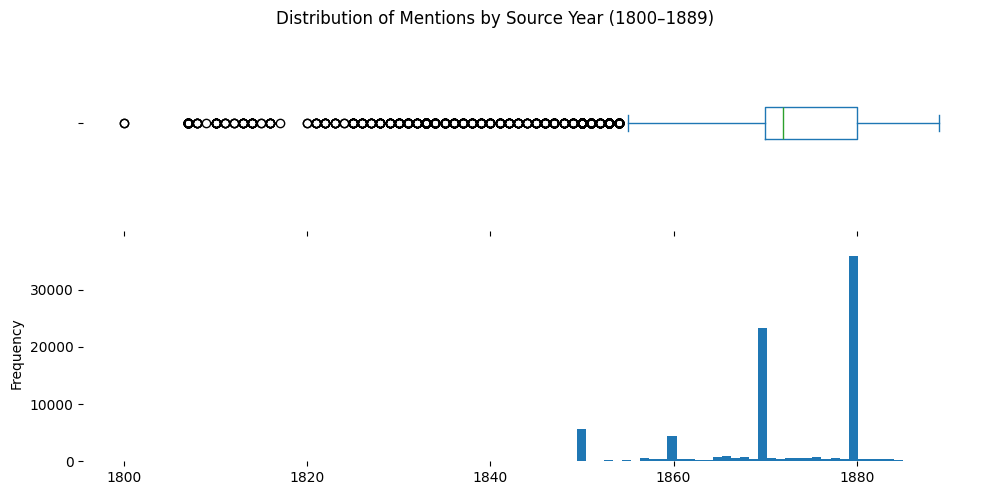

In [252]:
date_range = (MENTION.source_year >= 1800) & (MENTION.source_year < 1890)
X = MENTION[date_range].source_year

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,5))

X.plot.box(ax=axes[0], vert=False)
X.plot.hist(ax=axes[1], bins=90)

axes[0].set_yticklabels("")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.suptitle("Distribution of Mentions by Source Year (1800–1889)")
plt.show()

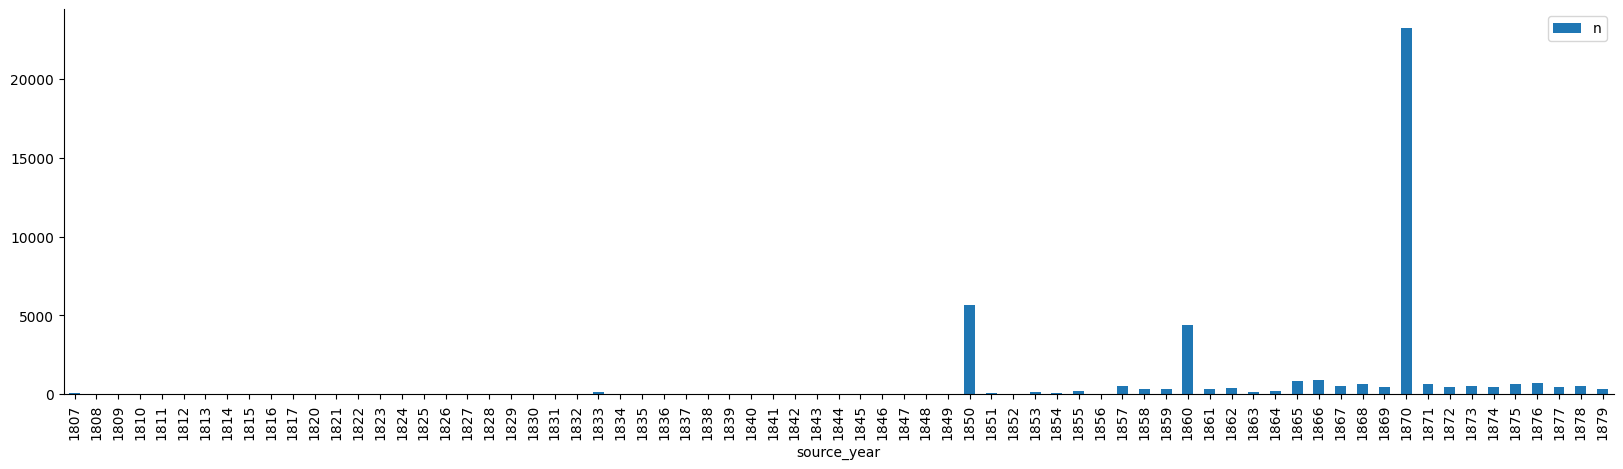

In [251]:
(
    MENTION[(MENTION.source_year > 1800) & (MENTION.source_year < 1880)]
    .value_counts('source_year')
    .to_frame('n')
    .sort_index()
    .plot.bar(figsize=(20,5))
)
sns.despine()

### Distribution of Birth Years in MENTION

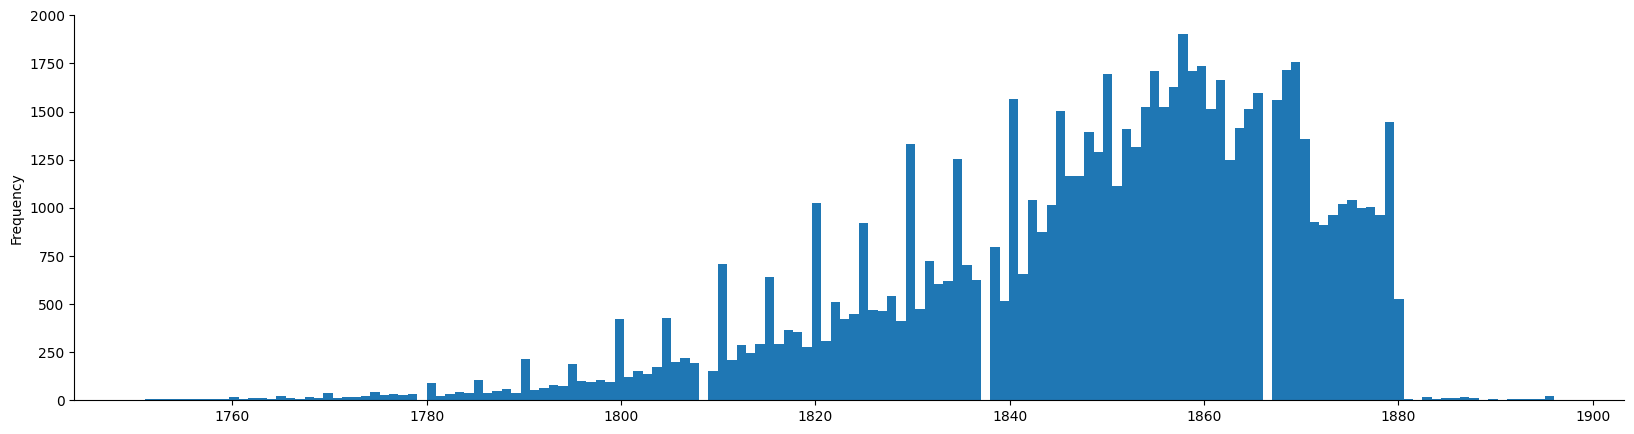

In [256]:
MENTION[MENTION.birth_year > 1750].birth_year.plot.hist(bins=150, figsize=(20,5))
sns.despine()
plt.show()

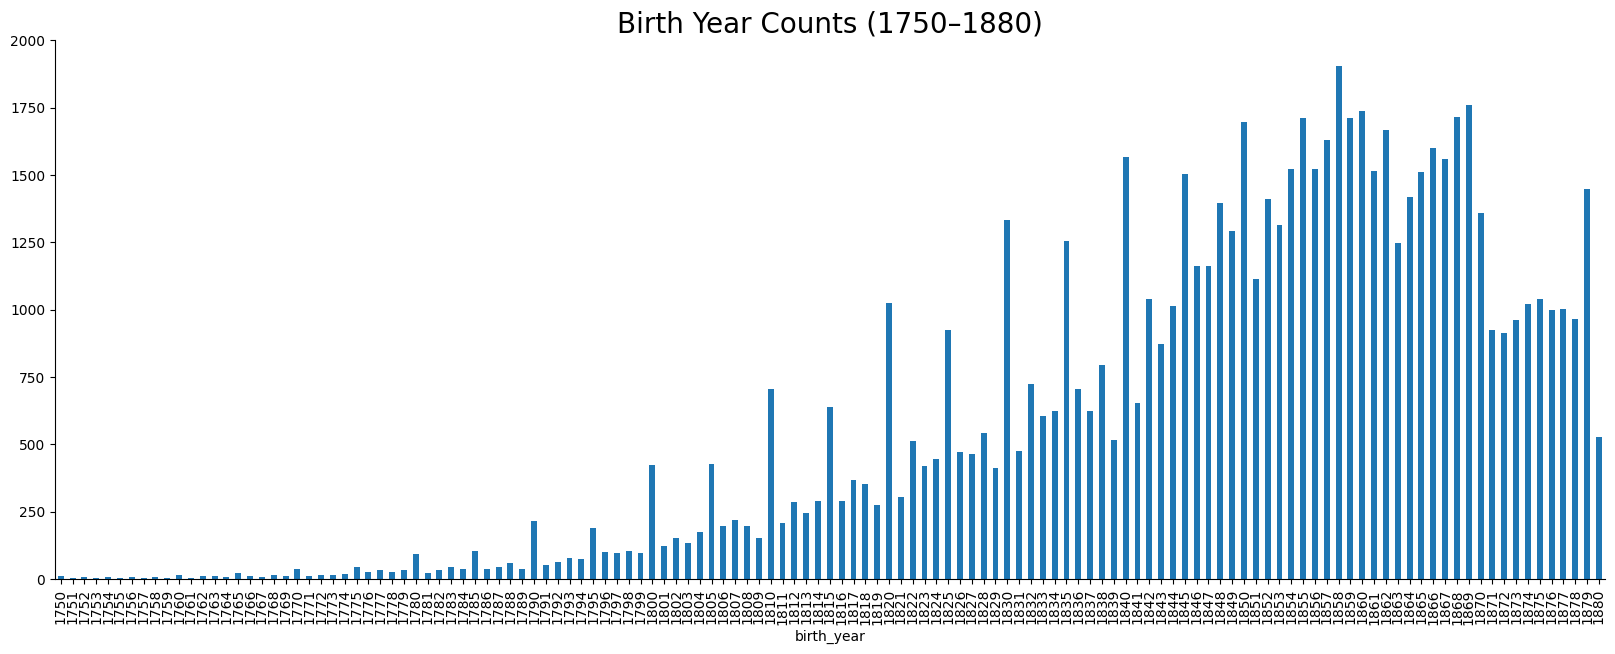

In [259]:
X = MENTION[(MENTION.birth_year >= 1750) & (MENTION.birth_year < 1881)].birth_year.value_counts().sort_index()
X.plot.bar(x='birth_year', y='n', figsize=(20,7))
plt.title("Birth Year Counts (1750–1880)", fontsize=20)
sns.despine()
plt.show()

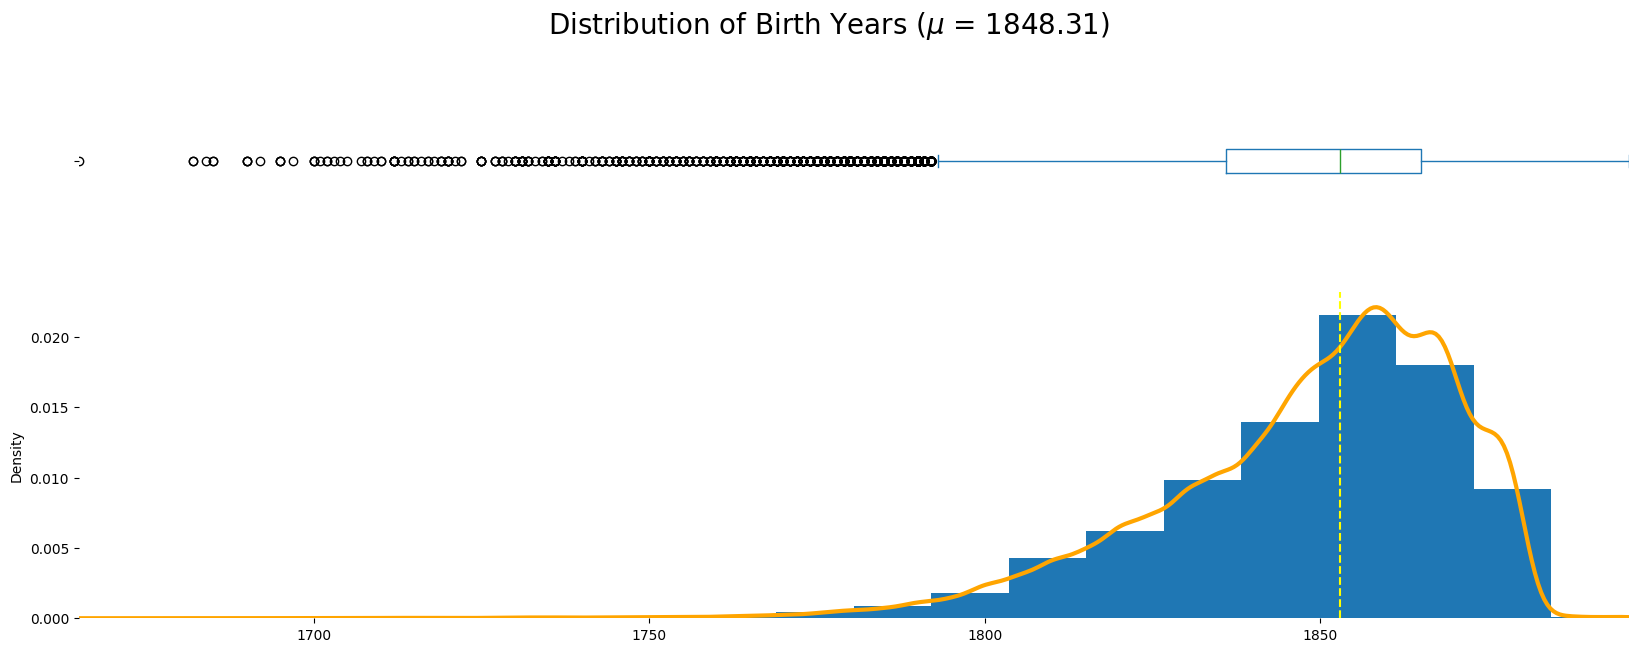

In [261]:
X = MENTION.loc[MENTION.birth_year > 188, 'birth_year']

fig, axes = plt.subplots(2, 1, figsize=(20, 7), sharex=True,
    gridspec_kw={'height_ratios': [1, 2]})

X.plot.box(ax=axes[0], vert=False)
X.plot.hist(ax=axes[1], bins=20, density=True)
X.plot.kde(ax=axes[1], color='orange', lw=3)

axes[0].set_yticklabels([])
axes[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
axes[1].axvline(X.median(), color='yellow', ls='--')
axes[0].set_xlim(X.min(), X.max())
axes[1].set_xlim(X.min(), X.max())

sns.despine(left=True, bottom=True)
plt.suptitle(rf"Distribution of Birth Years ($\mu$ = {MENTION.birth_year.mean().round(2)})", fontsize=20)
plt.show()

### Identify Unique Person Keys in MENTION

In [ ]:
PERSON = MENTION.value_counts('person_key').to_frame('n_mentions')
PERSON['mention_ids'] = MENTION.reset_index().groupby('person_key').mention_id.apply(lambda x: list(x))
PERSON['all_same'] = None

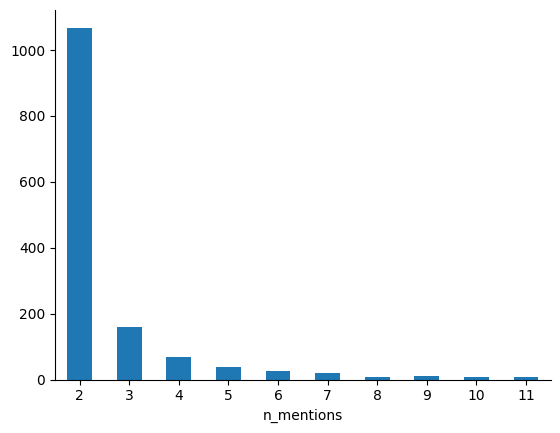

In [262]:
PERSON[PERSON.n_mentions > 1].n_mentions.value_counts().sort_index().head(10).plot.bar(rot=0)
sns.despine()
plt.show()

In [54]:
answer = widgets.ToggleButtons(
    options=['True', 'False'],
    description='Question: Are these the same person?',
    value=None
)

In [55]:
n = 4
sample = PERSON[PERSON.n_mentions == n].sample()
test_ids = sample.mention_ids.to_list()[0]
test_person = sample.index.to_list()[0]
print(test_person)
print(test_ids)
MENTION.loc[test_ids].sort_values('source_year').T.dropna()

xxxx-x-x-f-minerva
['907a66e2-1bdd-4c1e-b098-8329613785fe', 'ff52b7d6-0034-4ab7-8d6e-057703ff0453', 'ee8b4ac0-19ab-4e64-b0a8-f7b820e37200', '4e0891d4-4183-4eb3-bcc0-4aa9355221b5']


mention_id,4e0891d4-4183-4eb3-bcc0-4aa9355221b5,907a66e2-1bdd-4c1e-b098-8329613785fe,ff52b7d6-0034-4ab7-8d6e-057703ff0453,ee8b4ac0-19ab-4e64-b0a8-f7b820e37200
source,ALB_VR_1715,ALB_VR_1715,ALB_VR_1715,ALB_VR_1715
source_year,1864,1867,1883,1885
confidence,0.85,0.85,0.85,0.85
full_name,Minerva,Minerva,Minerva,Minerva
first_name,Minerva,Minerva,Minerva,Minerva
last_name,Minerva,Minerva,Minerva,Minerva
gender,F,F,F,F
norm_first_name,MINERVA,MINERVA,MINERVA,MINERVA
nysiis_last_name,MINE,MINE,MINE,MINE
person_key,xxxx-x-x-f-minerva,xxxx-x-x-f-minerva,xxxx-x-x-f-minerva,xxxx-x-x-f-minerva


In [56]:
display(answer)

ToggleButtons(description='Question: Are these the same person?', options=('True', 'False'), value=None)

In [57]:
if answer.value:
    # Assert that these are the same somewhere
    print(f"Asserting {test_person} True")
    PERSON.loc[test_person, 'all_same'] = True
PERSON[PERSON.all_same == True]

,n_mentions,mention_ids,all_same
person_key,,,


### Explore predicates in ASSERTION

In [58]:
PREDICATE = ASSERTION.value_counts('predicate')
PREDICATE

predicate
isSiblingOf         18067
isChildOf           12604
isParentOf          12604
wasEnslavedBy        8251
isSpouseOf           4520
IsMotherOf           2222
isGrandParentOf      1890
isGrandChildOf       1890
IsFatherOf           1564
isNiblingOf           179
isPiblingOf           179
isSiblingInLawOf       84
isParentInLawOf        63
isChildInLawOf         57
isCousinOf             25
isGrandmotherOf         9
isGrandfatherOf         1
Name: count, dtype: int64

### Join MENTION and ASSERTION

In [59]:
con.sql("""
CREATE OR REPLACE VIEW assertion_v AS
SELECT m1.person_key AS 'subject_key', predicate, m2.person_key AS 'object_key', a.subject_id, a.object_id
    FROM assertion a 
        JOIN mention m1 ON m1.mention_id = a.subject_id
        JOIN mention m2 ON m2.mention_id = a.object_id
""")
A = con.sql("select * from assertion_v").df()

In [60]:
A.sort_values('subject_key')

,subject_key,predicate,object_key,subject_id,object_id
56560,1750-e-b-f-x,wasEnslavedBy,xxxx-x-x-x-william_rothwell,d20ff507-09ed-48d0-b4db-beb616f9b8b1,aaa46f22-9e31-4391-ae3f-ef37159fa7a0
59030,1750-e-b-f-x,wasEnslavedBy,xxxx-x-x-x-john_j_bowcock,c9726eff-befc-4de2-9131-9d30419a0e72,3828e268-f536-4102-8b14-bac0172cb170
57598,1750-e-b-m-x,wasEnslavedBy,xxxx-x-x-x-colvin_cradock,847038d8-a520-4ef2-81f9-d111bdb201c4,c4a62f0e-31b9-497d-88d3-409c4adb36f5
910,1760-e-b-f-x,wasEnslavedBy,xxxx-x-x-x-v_a_a_t_douglass,eaa9d07d-d74c-49a9-98a7-d9ad46d3c06e,2578db26-a2f3-4b0b-95a0-dfbbd5c08dbe
56093,1760-e-b-f-x,wasEnslavedBy,xxxx-x-x-x-edwin_douglas,68d217ee-a516-4f14-9500-7d99181329fa,b3f91fa0-dddf-4d51-96e7-ebf60ab12a23
...,...,...,...,...,...
55735,xxxx-x-x-m-zach_ragland,IsFatherOf,1857-x-b-m-andrew_ragland,0587afb6-3b99-454f-bf26-7a40da9d0756,b09ee651-03d1-446f-9417-9b5729c3f8e0
55611,xxxx-x-x-m-zach_wood,IsFatherOf,1822-x-b-m-william_wood,99dc1112-4f19-4aab-81e0-3817dcb0a58e,f4eea0a5-b68d-4ae6-8b92-22dbfcc5df22
55125,xxxx-x-x-m-zack_harvey,IsFatherOf,xxxx-x-x-x-benjamin_harvey,2dc26c5c-7030-4b0c-91ce-8d52132ae1b4,80f6e65f-a9a2-49fc-92d8-71f347d160f5
38314,xxxx-x-x-m-zebudee_burnett,IsFatherOf,xxxx-x-x-x-john_b*ette,d7d4c069-88ee-4dee-89ec-0529b3988e51,d7f1e863-1690-4550-ba95-1989a8a42b0b


#### Extract RELATION

In [61]:
RELATION = A.value_counts(['subject_key','predicate','object_key']).to_frame('n_assertions')

In [62]:
RELATION.head()

,,,n_assertions
subject_key,predicate,object_key,
1846-e-b-m-x,wasEnslavedBy,xxxx-x-x-x-john_s_cocke,3
1845-e-b-m-x,wasEnslavedBy,xxxx-x-x-x-l_w_maupin,2
1854-e-b-m-x,wasEnslavedBy,xxxx-x-x-x-w_w_miner,2
1859-e-b-m-x,wasEnslavedBy,xxxx-x-x-x-a_w_gantt,2
xxxx-e-b-m-x,wasEnslavedBy,xxxx-x-x-x-j_w_elsom,2


Get relations for a given person.

In [63]:
RELATION.loc['1852-f-b-m-david_tompson']

n_assertions
predicate   object_key                             
isSiblingOf 1859-f-b-f-bettie_tompson             1
            1862-f-b-f-fanny_tompson              1
            1864-f-b-f-beckie_tompson             1
            1855-f-b-m-henry_tompson              1
isChildOf   1825-f-b-m-james_tompson              1

In [64]:
p = RELATION.sample().index[0][0]
# p = PERSON.sample().index.values[0]
print(p, ":", sep="")
try:
    relations = RELATION.loc[p].sort_index().reset_index().values
    for rel in relations:
        print("-- ", end="")
        print(rel[0], rel[1], sep="\t")
except KeyError as e:
    print("-- Has no recorded relations.")

1855-f-w-f-roberta_v_arnold:
-- isChildOf	1825-f-w-f-mary_arnold
-- isSiblingOf	1849-f-w-f-cornelia_w_arnold
-- isSiblingOf	1851-f-w-m-arthur_d_arnold


Add RELATION counts to PERSON.

In [65]:
PERSON['n_relations'] = RELATION.reset_index().subject_key.value_counts()
PERSON.n_relations = PERSON.n_relations.fillna(0)
PERSON.n_relations = PERSON.n_relations.astype(int)

In [66]:
PERSON['n_relations_as_object'] = RELATION.reset_index().object_key.value_counts()
PERSON.n_relations_as_object = PERSON.n_relations_as_object.fillna(0)
PERSON.n_relations_as_object = PERSON.n_relations_as_object.astype(int)

In [67]:
PERSON.sort_values('n_relations', ascending=False)

,n_mentions,mention_ids,all_same,n_relations,n_relations_as_object
person_key,,,,,
1849-e-b-m-x,130,"[9555b2af-75de-4737-a1a4-c9f4b9d32967, 51a2e9d...",None,124,0
1848-e-b-f-x,131,"[1eb7160b-74f6-440f-b9cf-65a9a2bf6a68, 54855bb...",None,123,0
1848-e-b-m-x,127,"[130ff3c8-b6c8-4445-8afb-a7f2141761b3, 9224d43...",None,121,0
1842-e-b-f-x,127,"[92aefbb0-3749-4cae-9569-83de233de5b1, 5e05edd...",None,120,0
1842-e-b-m-x,125,"[9019a798-f050-43e3-851d-80464be6a25b, 72b6fa9...",None,120,0
...,...,...,...,...,...
1876-x-x-x-julia_gibson,1,[1dd2f8e6-ed11-42ff-8bfe-c4b88d25dd60],None,0,0
xxxx-x-x-x-isham_abskine,1,[3ad59a9b-1017-4b7f-a5c2-55295be97edf],None,0,0
1860-x-x-x-parker,1,[47d3ecab-d842-4729-b39c-5026d17febff],None,0,0


In [68]:
PERSON.sample(10)

,n_mentions,mention_ids,all_same,n_relations,n_relations_as_object
person_key,,,,,
1846-f-w-f-mary_a_madison,1,[6972090a-3dda-410e-b141-9f13098b9f1e],None,2,2
xxxx-x-x-m-b_b_shelton,1,[9d96a6e5-f374-4855-b115-970e3c3a7abe],None,0,0
1860-f-b-f-mary_f_scott,1,[39adb849-263c-4dd2-a7c3-49e64558c952],None,2,2
1868-x-b-m-samuel_lott,1,[c65394b4-cdb1-46d1-97f1-2f41ef228a06],None,0,0
1820-f-w-m-jacob_speck,1,[69d16e60-be3c-4e92-bb65-7a17ee3c2326],None,0,0
1848-f-b-m-bowling_perkins,1,[ba126d6a-3f18-42ba-9c69-d1d4dff4ab24],None,0,0
xxxx-x-x-f-lockey_crouch,1,[166bb7b4-124a-4841-b48d-a880ac28844a],None,0,0
1876-f-w-f-maria_w_ranson,1,[efb07b79-a29b-4c64-96c7-21ae10ed5025],None,0,0
1874-f-w-m-happer_bumgardner,1,[44eb97ec-6ef1-4da8-83f9-00e2d2474707],None,0,0


In [69]:
RELATION.loc['1863-f-w-m-edward_c_harrison']

n_assertions
predicate      object_key                                
isGrandChildOf 1804-f-w-f-jane_r_harrison               1
isChildOf      1823-f-w-m-henry_harrison                1
isSiblingOf    1859-f-w-m-randolph_harrison             1
               1865-f-w-m-beverly_harrison              1
               1857-f-w-f-jane_r_harrison               1

#### Wide version

In [70]:
X = A.value_counts(['predicate','object_key','subject_key']).unstack(fill_value=0).T.sort_index().astype(int)
X.columns.names = [None,None]

In [71]:
X

wasEnslavedBy                           \
                           xxxx-x-x-x-i_pettet xxxx-x-x-x-hudson_burton   
subject_key                                                               
1750-e-b-f-x                                 0                        0   
1750-e-b-m-x                                 0                        0   
1760-e-b-f-x                                 0                        0   
1762-e-b-m-x                                 0                        0   
1765-e-b-f-x                                 0                        0   
...                                        ...                      ...   
xxxx-x-x-m-zach_ragland                      0                        0   
xxxx-x-x-m-zach_wood                         0                        0   
xxxx-x-x-m-zack_harvey                       0                        0   
xxxx-x-x-m-zebudee_burnett                   0                        0   
xxxx-x-x-m-{blank]                           0                        0   

                                                                            \
                           xxxx-x-x-x-ira_a_miller xxxx-x-x-x-thos_f_lewis   
subject_key                                                                  
1750-e-b-f-x                                     0                       0   
1750-e-b-m-x                                     0                       0   
1760-e-b-f-x                                     0                       0   
1762-e-b-m-x                                     0                       0   
1765-e-b-f-x                                     0                       0   
...                                            ...                     ...   
xxxx-x-x-m-zach_ragland                          0                       0   
xxxx-x-x-m-zach_wood                             0                       0   
xxxx-x-x-m-zack_harvey                           0                       0   
xxxx-x-x-m-zebudee_burnett                       0                       0   
xxxx-x-x-m-{blank]                               0                       0   

                                                                        \
                           xxxx-x-x-x-r_l_walker xxxx-x-x-x-w_h_massie   
subject_key                                                              
1750-e-b-f-x                                   0                     0   
1750-e-b-m-x                                   0                     0   
1760-e-b-f-x                                   0                     0   
1762-e-b-m-x                                   0                     0   
1765-e-b-f-x                                   0                     0   
...                                          ...                   ...   
xxxx-x-x-m-zach_ragland                        0                     0   
xxxx-x-x-m-zach_wood                           0                     0   
xxxx-x-x-m-zack_harvey                         0                     0   
xxxx-x-x-m-zebudee_burnett                     0                     0   
xxxx-x-x-m-{blank]                             0                     0   

                                                                       \
                           xxxx-x-x-x-g_f_holmes xxxx-x-x-x-g_f_coles   
subject_key                                                             
1750-e-b-f-x                                   0                    0   
1750-e-b-m-x                                   0                    0   
1760-e-b-f-x                                   0                    0   
1762-e-b-m-x                                   0                    0   
1765-e-b-f-x                                   0                    0   
...                                          ...                  ...   
xxxx-x-x-m-zach_ragland                        0                    0   
xxxx-x-x-m-zach_wood                           0                    0   
xxxx-x-x-m-zack_harvey                         0 

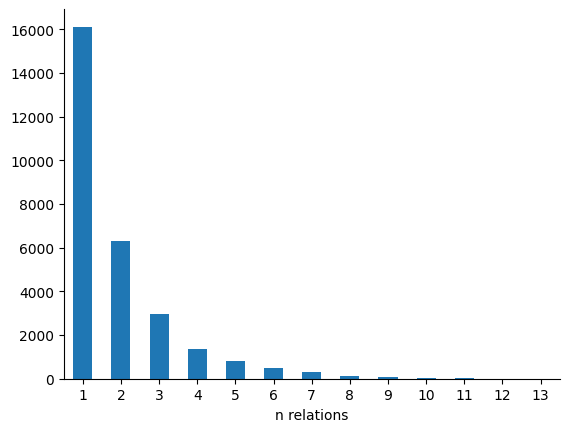

In [72]:
ax = X.T.sum().sort_values().value_counts().sort_index().head(13).plot.bar(logx=False, logy=False, rot=0)
ax.set_xlabel("n relations")
sns.despine()
# plt.title("Counts of Relations Numbers")
plt.show()

## Save

In [73]:
MENTION.to_parquet("MENTION.parquet", index=True)
ASSERTION.to_parquet("ASSERTION.parquet", index=True)
PERSON.to_parquet("PERSON.parquet", index=True)
RELATION.to_parquet("RELATION.parquet", index=True)
A.to_parquet("A.parquet", index=True)
X.to_parquet("X_wide.parquet")